<h1>Train — AlexNet</h1>

Trains and evaluates AlexNet **from scratch (no ImageNet pretraining)** using the hand-picked hyperparameters from `ARCH_HYPERPARAMS["alexnet"]`, then saves its results and weights to disk for the results notebook. Unlike every other architecture here, this one starts from random weights instead of a pretrained backbone -- included to see how a small CNN trained from scratch on this dataset compares to the transfer-learning models.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["alexnet"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"AlexNet: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

AlexNet: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (AlexNet, trained from scratch -- no pretrained weights)
# ---------------------------------------------------------
model = models.alexnet(weights=None)  # no ImageNet pretraining, unlike every other architecture here

# AlexNet's classifier is nn.Sequential(Dropout, Linear, ReLU, Dropout, Linear,
# ReLU, Linear) — swap out just the final Linear layer (index 6) for our
# (optionally deeper) classifier head, same as the fc/classifier swaps used
# for the other architectures.
in_f = model.classifier[6].in_features
model.classifier[6] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[AlexNet] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[AlexNet] Epoch   1/100 | LR: 1.00e-04 | train loss 1.0549 acc 0.468 | val loss 0.8338 acc 0.695 *


[AlexNet] Epoch   2/100 | LR: 1.00e-04 | train loss 0.9345 acc 0.666 | val loss 0.8415 acc 0.707


[AlexNet] Epoch   3/100 | LR: 1.00e-04 | train loss 0.8823 acc 0.690 | val loss 0.7535 acc 0.689 *


[AlexNet] Epoch   4/100 | LR: 1.00e-04 | train loss 0.8193 acc 0.700 | val loss 0.8145 acc 0.622


...

[AlexNet] Epoch  96/100 | LR: 1.00e-10 | train loss 0.1213 acc 0.964 | val loss 0.7303 acc 0.765


[AlexNet] Epoch  97/100 | LR: 1.00e-10 | train loss 0.1169 acc 0.968 | val loss 0.7303 acc 0.765


[AlexNet] Epoch  98/100 | LR: 1.00e-10 | train loss 0.1210 acc 0.964 | val loss 0.7304 acc 0.765


[AlexNet] Epoch  99/100 | LR: 1.00e-10 | train loss 0.1164 acc 0.968 | val loss 0.7304 acc 0.765


[AlexNet] Epoch 100/100 | LR: 1.00e-10 | train loss 0.1174 acc 0.964 | val loss 0.7304 acc 0.765

[AlexNet] Restored best checkpoint (val loss = 0.5446)


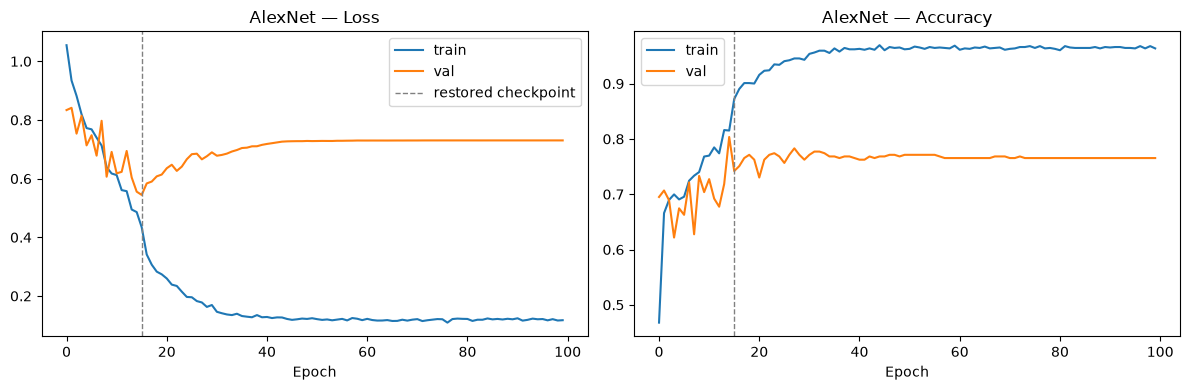

In [4]:
# No early stopping (patience=None): from random init AlexNet can sit on a
# ~ln(4) loss plateau for many epochs before it starts learning, and noisy
# val loss during that plateau made early stopping quit too soon.
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, None, "AlexNet", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "AlexNet")

## Evaluate on the test set

[AlexNet] Test accuracy: 0.721


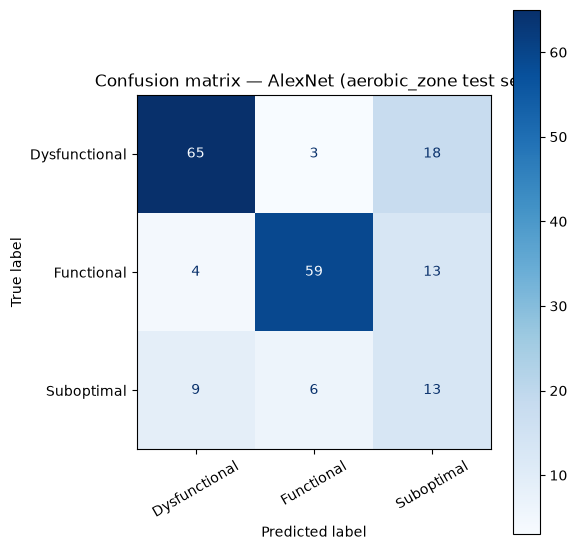

               precision    recall  f1-score   support

Dysfunctional      0.833     0.756     0.793        86
   Functional      0.868     0.776     0.819        76
   Suboptimal      0.295     0.464     0.361        28

     accuracy                          0.721       190
    macro avg      0.665     0.665     0.658       190
 weighted avg      0.768     0.721     0.740       190



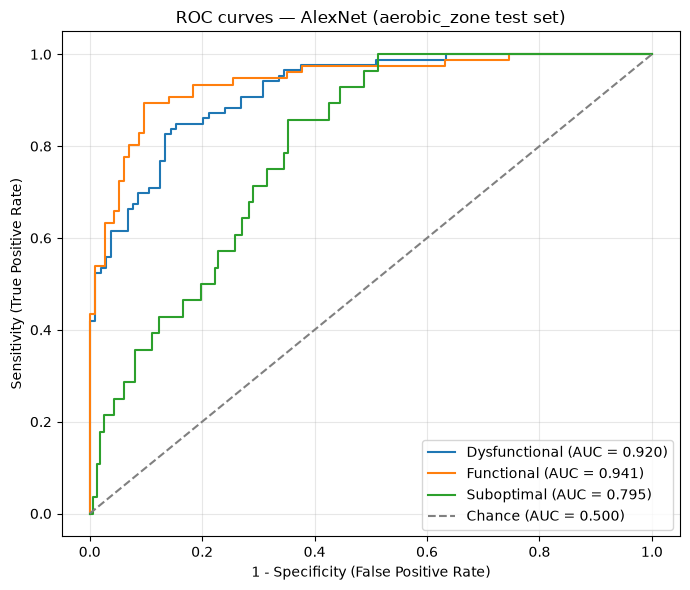

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.920
  Functional     : 0.941
  Suboptimal     : 0.795

Mean AUC (over 3/3 classes with test examples): 0.885


(np.float64(0.7210526315789474),
 {'Dysfunctional': 0.9198345259391771,
  'Functional': 0.9405586334256695,
  'Suboptimal': 0.7947530864197532})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "AlexNet", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("AlexNet", "alexnet")

Saved results to ../results/aerobic_zone_noaug/results_aerobic_zone_alexnet_stratified.pkl


Saved model weights to ../models/aerobic_zone_alexnet_cnn.pt
